<a href="{{ colab_base_laboratorios }}/Laboratorio_06_normal_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 6 : Ecuación normal

Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.

Los pasos para esta minimizacion se dejan como tarea, y pueden ser calculados según lo siguiente:

Si J es la funcion de coste dada por:

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}


Demostrar que:

- $J(\theta_1,\theta_2,\theta_3, ...,\theta_n ) = \frac{1}{2m} (\Theta ^ T X - y^T) (\Theta ^ T X - y^T)^T$

- $J= (\Theta ^T X) (\Theta ^T X)^T - 2(\Theta ^T X)Y  + Y^TY $


- $ \nabla _{\theta} J = \frac{1}{m} (2 X(X^T \Theta) -2XY)$


Para encontrar el valor minimo de \theta,  $\nabla _{\theta} J = 0$,

- $\Theta = (X^T X)^{-1} X^T y$



En este caso,tenemos que:

sea $X \in R^{n\times m}$ ,  $X^T \in R^{m\times n}$

sea $Y \in R^{m \times 1}$,  $Y^T \in R^{1 \times m}$

sea $\Theta \in R^{n \times 1}$, $\Theta^T \in R^{1 \times n}$




Para la demostracion anterior emplee las siguientes propiedades:

- $z^T z= \sum_i z_i^2$
- $a^T b = b^Ta$
- $\nabla _x b^T x = b$
- $\nabla _x  x^T A x = 2Ax$

donde a, b, x son matrices, $\nabla_x$ es la derivada respecto al vector x, y A es una matriz simétrica




## Demostración: Ecuación Normal

**Convención:** $X \in \mathbb{R}^{m \times n}$ (m muestras, n features), $\Theta \in \mathbb{R}^{n \times 1}$, $Y \in \mathbb{R}^{m \times 1}$.

---

### Propiedades utilizadas

1. $z^T z = \sum_i z_i^2$
2. $a^T b = b^T a$
3. $\nabla_x \, b^T x = b$
4. $\nabla_x \, x^T A x = 2Ax$, donde $A$ es simétrica
5. $(AB)^T = B^T A^T$

---

### Paso 1 — Forma matricial de $J$

Sea $e = X\Theta - Y \in \mathbb{R}^{m \times 1}$ el vector de errores. Por la propiedad **1**:

$$J(\Theta) = \frac{1}{2m}\sum_{i=1}^{m}(x^{(i)T}\Theta - y^{(i)})^2 = \frac{1}{2m}(X\Theta - Y)^T(X\Theta - Y)$$

---

### Paso 2 — Expansión

Expandiendo el producto y aplicando la propiedad **5** para obtener $(X\Theta)^T = \Theta^T X^T$:

$$(X\Theta - Y)^T(X\Theta - Y) = \Theta^T X^T X \Theta - \Theta^T X^T Y - Y^T X\Theta + Y^T Y$$

Los dos términos del medio son escalares e iguales por la propiedad **2**, por lo tanto:

$$J = \frac{1}{2m}\left(\Theta^T X^T X \Theta - 2\Theta^T X^T Y + Y^T Y\right)$$

---

### Paso 3 — Gradiente

Aplicando **4** al término cuadrático (con $A = X^T X$, que es simétrica) y **3** al término lineal:

$$\nabla_\Theta J = \frac{1}{m}\left(X^T X \Theta - X^T Y\right)$$

---

### Paso 4 — Mínimo

Igualando $\nabla_\Theta J = 0$:

$$X^T X \Theta = X^T Y$$

$$\boxed{\Theta = (X^T X)^{-1} X^T Y}$$

1. Para los datos del laboratorio anterior aplicar la ecuacion normal.

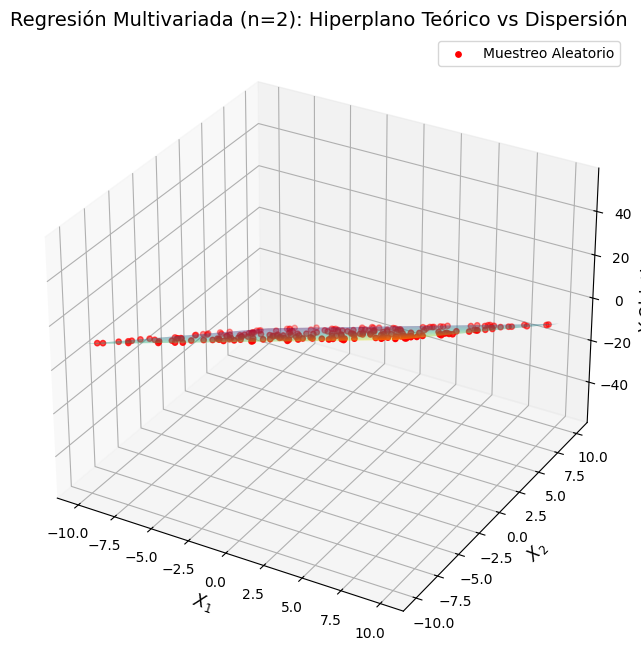

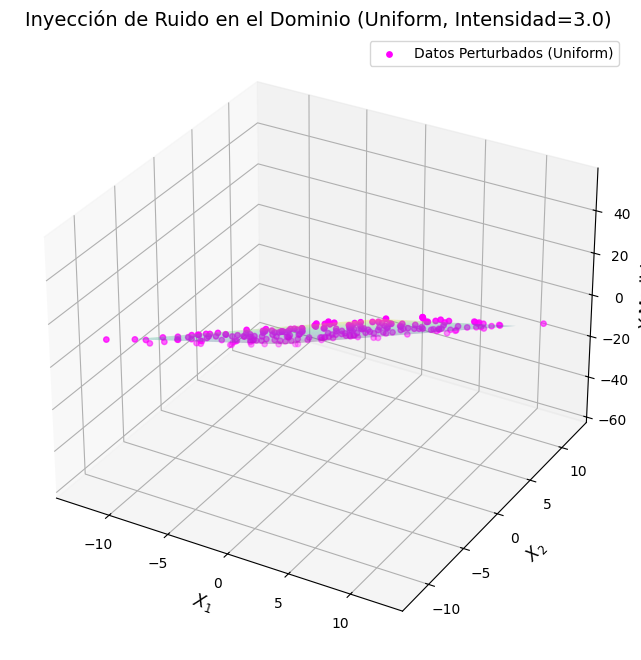

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pandas as pd
import time

def generar_y_graficar_plano(func_eval, n, m, span, random_state=None):
    """
    Genera un conjunto de datos multivariados a partir de un hiperplano definido
    por una función lambda y visualiza los datos en 3D si n=2.

    Args:
        func_eval (callable): Función lambda que toma una matriz de características y devuelve la variable objetivo.
        n (int): Cantidad geométrica de características (features independientes).
        m (int): Cantidad de muestras o instancias temporales/mediciones.
        span (float): Límite absoluto de dominio simétrico; x_i ∈ [-span, span].
        random_state (int, opcional): Semilla algorítmica para asegurar reproducibilidad.

    Returns:
        tuple:
            - X_raw (np.ndarray): Matriz de características (n, m).
            - Y (np.ndarray): Vector objetivo generado teóricamente (1, m).
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    # Extracción de características bajo una distribución de probabilidad uniforme
    X_raw = 2 * span * np.random.random((n, m)) - span
    
    # Inyección a través de la relación funcional dictada por el ejercicio
    Y = func_eval(X_raw)
    # Reformatear estructuradamente como (1, m) en caso de que devuelva un vector plano
    Y = Y.reshape(1, -1)
    
    # Condición geométrica para graficar (Solo se puede desplegar un plano estático en 3D si n=2)
    if n == 2:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Malla teórica (Grid)
        grid_vals = np.linspace(-span, span, 50)
        x1_grid, x2_grid = np.meshgrid(grid_vals, grid_vals)
        # Vectorizar el dominio en forma (2, N)
        grid_input = np.vstack([x1_grid.ravel(), x2_grid.ravel()])
        z_grid = func_eval(grid_input).reshape(x1_grid.shape)
        
        # Trazo de la superficie (hiperplano bidimensional)
        ax.plot_surface(x1_grid, x2_grid, z_grid, alpha=0.5, cmap='viridis')
        # Trazo numérico de la dispersión de datos sintéticos
        ax.scatter(X_raw[0, :], X_raw[1, :], Y.ravel(), color='red', s=15, label='Muestreo Aleatorio')
        
        ax.set_title("Regresión Multivariada (n=2): Hiperplano Teórico vs Dispersión", fontsize=14)
        ax.set_xlabel('$X_1$', fontsize=12)
        ax.set_ylabel('$X_2$', fontsize=12)
        ax.set_zlabel('$Y$ Objetivo', fontsize=12)
        plt.legend()
        plt.show()
    else:
        print(f"[*] Dataset generado exitosamente con {n} características y {m} registros. (Sin visualización para n != 2)")
        
    return X_raw, Y

def inyectar_ruido_y_graficar(X_raw, func_eval, noise_type='gaussian', intensity=1.0, span=10.0, random_state=None):
    """
    Añade ruido estocástico (gaussiano o uniforme) a una matriz de características 
    y grafica el conjunto perturbado contra el hiperplano original. Útil para 
    evaluar la robustez del modelo (o simular errores de medición).

    Args:
        X_raw (np.ndarray): Matriz original de características (n, m).
        func_eval (callable): Función matemática del hiperplano referencial.
        noise_type (str): Distribución estadística a inyectar ('gaussian' o 'uniform').
        intensity (float): Desviación estándar (para gaussiano) o magnitud del límite (para uniforme).
        span (float): Límite absoluto para graficar la superficie de control.
        random_state (int, opcional): Semilla algorítmica para reproducibilidad.

    Returns:
        np.ndarray: Nueva matriz de características con el perfil de ruido especificado (n, m).
    """
    if random_state is not None:
        np.random.seed(random_state)
        
    n, m = X_raw.shape
    
    # 1. Inyección estocástica parametrizada
    if noise_type == 'gaussian':
        # Ruido Blanco Gaussiano N(0, sigma^2)
        noise = np.random.normal(loc=0.0, scale=intensity, size=(n, m))
    elif noise_type == 'uniform':
        # Ruido Equivalente Uniforme U(-a, a)
        noise = np.random.uniform(low=-intensity, high=intensity, size=(n, m))
    else:
        raise ValueError("El parámetro noise_type debe ser explícitamente 'gaussian' o 'uniform'.")
        
    X_noisy = X_raw + noise
    
    # 2. Inferencia espacial para visualización
    # Recalculamos Y únicamente para despliegue topológico
    Y_noisy = func_eval(X_noisy).reshape(1, -1)
    
    # 3. Gráficos en 3D
    if n == 2:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Malla de control geométrico (Sin ruido)
        grid_vals = np.linspace(-span, span, 50)
        x1_grid, x2_grid = np.meshgrid(grid_vals, grid_vals)
        grid_input = np.vstack([x1_grid.ravel(), x2_grid.ravel()])
        z_grid = func_eval(grid_input).reshape(x1_grid.shape)
        
        ax.plot_surface(x1_grid, x2_grid, z_grid, alpha=0.3, cmap='viridis')
        ax.scatter(X_noisy[0, :], X_noisy[1, :], Y_noisy.ravel(), color='magenta', s=15, 
                   label=f'Datos Perturbados ({noise_type.capitalize()})')
        
        ax.set_title(f"Inyección de Ruido en el Dominio ({noise_type.capitalize()}, Intensidad={intensity})", fontsize=14)
        ax.set_xlabel('$X_1$', fontsize=12)
        ax.set_ylabel('$X_2$', fontsize=12)
        ax.set_zlabel('$Y$ Medido', fontsize=12)
        plt.legend()
        plt.show()
        
    return X_noisy

# --- Demostración del Punto 1 ---
# Definición de la ecuación requerida: y = 2.1*x1 - 3.1*x2
func_hiperplano = lambda x: 2.1 * x[0, :] - 3.1 * x[1, :]

X_raw, Y_obj = generar_y_graficar_plano(
    func_eval=func_hiperplano, 
    n=2, 
    m=200, 
    span=10.0, 
    random_state=12
)

# Prueba de concepto: Generando el subconjunto ruidoso
X_ruidoso = inyectar_ruido_y_graficar(
    X_raw=X_raw,
    func_eval=func_hiperplano,
    noise_type='uniform',
    intensity=3.0,
    span=10.0,
    random_state=42
)

In [17]:
def compute_normal_equation(X: np.ndarray, y: np.ndarray, fit_intercept: bool = False) -> np.ndarray:
    """
    Calcula los parámetros óptimos (Theta) de una regresión lineal multivariada 
    utilizando la solución analítica exacta: la Ecuación Normal.

    La Ecuación Normal está definida matemáticamente como:
        Theta = (X^T * X)^(-1) * X^T * Y

    Args:
        X (np.ndarray): Matriz de diseño (features). Dimensionalidad esperada (m, n) 
            donde 'm' son muestras y 'n' son características.
        y (np.ndarray): Vector objetivo (target). Dimensionalidad esperada (m, 1).
        fit_intercept (bool): Si es True, añade una columna de 1s a 'X' para calcular 
            el término de sesgo/intercepto (theta_0).

    Returns:
        np.ndarray: Vector de parámetros óptimos Theta de forma (n, 1) o (n+1, 1).

    Raises:
        ValueError: Si (X^T * X) es una matriz singular (no invertible).
    """
    # 1. Ajuste de diseño (Intercepción)
    if fit_intercept:
        m = X.shape[0]
        # np.c_ concatena a lo largo del segundo eje (columnas)
        X_design = np.c_[np.ones((m, 1)), X]
    else:
        X_design = X
        
    # 2. Computación Algebraica
    # Operador '@' realiza multiplicación matricial (dot product) de forma legible
    try:
        theta_optimo = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
        return theta_optimo
    except np.linalg.LinAlgError:
        raise ValueError("Error Algebraico: Matriz (X^T X) singular. Inspecciona colinealidad en las variables independientes.")

# --- Aplicación Matemática sobre el dataset sintético ---

# La matriz X_raw (n, m) y el vector Y_obj (1, m) del bloque anterior no coinciden 
# con la formulación estándar (m, n) y (m, 1) de la demostración matricial.
# Transponemos para garantizar coherencia en el producto punto.
X_train = X_ruidoso.T  
Y_train = Y_obj.T  

# Ejecutamos la función (Sabemos que la función generadora cruzaba el origen, 
# por lo tanto fit_intercept = False)
theta_estimado = compute_normal_equation(X_train, Y_train, fit_intercept=False)

print("-" * 50)
print("  EVALUACIÓN DE ECUACIÓN NORMAL (ÁLGEBRA EXACTA)")
print("-" * 50)
print(f"  Theta_1 (Esperado:  2.1) -> Estimado: {theta_estimado[0, 0]:.4f}")
print(f"  Theta_2 (Esperado: -3.1) -> Estimado: {theta_estimado[1, 0]:.4f}")
print("-" * 50)

--------------------------------------------------
  EVALUACIÓN DE ECUACIÓN NORMAL (ÁLGEBRA EXACTA)
--------------------------------------------------
  Theta_1 (Esperado:  2.1) -> Estimado: 1.7817
  Theta_2 (Esperado: -3.1) -> Estimado: -2.9196
--------------------------------------------------


2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

```
# Tomar los datos de las casas de boston y hacer una regresion lineal tomando
# el average number of rooms per dwelling.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})

```

In [18]:
# 1. Ingesta de Datos desde el Repositorio de CMU
data_url = "http://lib.stat.cmu.edu/datasets/boston"
print("[*] Descargando y preprocesando el dataset de Boston...")

# Lectura saltando la metadata y asumiendo espacios irregulares
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# 2. Reestructuración Vectorizada (Data Wrangling Multivariado)
# Colapsamos los 13 features (11 del primer renglón + 2 del segundo renglón)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2] # Median Value

# Nombres oficiales de las características de Boston Housing
feature_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", 
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

# 3. Construcción del DataFrame Analítico Completo
df = pd.DataFrame(data, columns=feature_names)
df["TARGET"] = target

# ==========================================
# FUNCIONES DE CALIDAD DE DATOS (DS_AGENT)
# ==========================================

def handle_missing_values(df_input: pd.DataFrame, col_thresh: float = 0.30, row_thresh: float = 0.40) -> pd.DataFrame:
    """
    Analiza valores nulos y limpia el DataFrame para prevenir fallos en la inferencia.
    - Elimina features (columnas) con > 30% de instancias vacías/nulas.
    - Elimina registros (filas) con > 40% de features corruptas.
    """
    print("\n--- ANÁLISIS DE VALORES NULOS ---")
    df_clean = df_input.copy()
    
    # Análisis y eliminación por columna (Features)
    null_ratio_col = df_clean.isnull().mean()
    cols_to_drop = null_ratio_col[null_ratio_col > col_thresh].index.tolist()
    if cols_to_drop:
        print(f"[!] Eliminando columnas por exceso de nulos (> {col_thresh*100}%): {cols_to_drop}")
        df_clean.drop(columns=cols_to_drop, inplace=True)
    else:
        print(f"[v] Columnas íntegras: Ninguna supera el umbral del {col_thresh*100}% de nulos.")
        
    # Análisis y eliminación por fila (Registros)
    # axis=1 calcula el promedio de nulos evaluando a lo largo de cada fila individual
    null_ratio_row = df_clean.isnull().mean(axis=1)
    rows_to_drop = null_ratio_row[null_ratio_row > row_thresh].index.tolist()
    if rows_to_drop:
        print(f"[!] Eliminando {len(rows_to_drop)} registro(s) por déficit de información (> {row_thresh*100}% nulos).")
        df_clean.drop(index=rows_to_drop, inplace=True)
    else:
        print(f"[v] Filas íntegras: Ninguna supera el umbral del {row_thresh*100}% nulos.")
        
    # Reset del index vital para iteraciones seguras a futuro
    return df_clean.reset_index(drop=True)

def detect_outliers(df_input: pd.DataFrame, features: list) -> None:
    """
    Detecta y reporta atípicos (outliers) utilizando el método del Rango Intercuartílico (IQR).
    Mide la dispersión central de los datos, ideal en features con distribuciones asimétricas.
    """
    print("\n--- REPORTE DE OUTLIERS (Métrico: IQR) ---")
    for col in features:
        if col not in df_input.columns: 
            continue
        
        # Cálculos Estadísticos
        Q1 = df_input[col].quantile(0.25)
        Q3 = df_input[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Máscara booleana para detectar intrusos
        outliers_mask = (df_input[col] < lower_bound) | (df_input[col] > upper_bound)
        num_outliers = outliers_mask.sum()
        
        if num_outliers > 0:
            perc = (num_outliers / len(df_input)) * 100
            print(f" -> {col:<7}: {num_outliers:>4} outliers detectados ({perc:>4.1f}% del feature)")
    print("-" * 45)


# 4. Procesamiento Experimental
# Filtramos primero nulos para prevenir propagación de errores en el reporte IQR
df_clean = handle_missing_values(df, col_thresh=0.3, row_thresh=0.4)

# Detectar y perfilar ruidos por distribución (excluyendo la variable dependiente)
predictor_columns = [col for col in df_clean.columns if col != "TARGET"]
detect_outliers(df_clean, predictor_columns)

print("\nVista Preliminar: DataFrame Multivariado Depurado")
print("=" * 65)
print(df_clean.head())
df_clean.shape

[*] Descargando y preprocesando el dataset de Boston...

--- ANÁLISIS DE VALORES NULOS ---
[v] Columnas íntegras: Ninguna supera el umbral del 30.0% de nulos.
[v] Filas íntegras: Ninguna supera el umbral del 40.0% nulos.

--- REPORTE DE OUTLIERS (Métrico: IQR) ---
 -> CRIM   :   66 outliers detectados (13.0% del feature)
 -> ZN     :   68 outliers detectados (13.4% del feature)
 -> CHAS   :   35 outliers detectados ( 6.9% del feature)
 -> RM     :   30 outliers detectados ( 5.9% del feature)
 -> DIS    :    5 outliers detectados ( 1.0% del feature)
 -> PTRATIO:   15 outliers detectados ( 3.0% del feature)
 -> B      :   77 outliers detectados (15.2% del feature)
 -> LSTAT  :    7 outliers detectados ( 1.4% del feature)
---------------------------------------------

Vista Preliminar: DataFrame Multivariado Depurado
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.

(506, 14)

In [19]:
# 1. Separación de Variables Independientes (X) y Dependiente (Y)
# Nota: Originalmente Boston Housing tiene 13 features que conservamos en df_clean.
X_boston = df_clean.drop(columns=['TARGET']).values
Y_boston = df_clean['TARGET'].values.reshape(-1, 1)

print("--- DIMENSIONES DEL CONJUNTO DE DATOS ---")
print(f"Matriz de características (X): {X_boston.shape} -> m={X_boston.shape[0]} muestras, n={X_boston.shape[1]} features")
print(f"Vector objetivo (Y):           {Y_boston.shape}")

# 2. Aplicación de la Ecuación Normal
# Activamos fit_intercept=True ya que un modelo de predicción de precios realistas 
# requiere un sesgo (el precio base no es estrictamente cero cuando las features son cero).

start_time = time.time()
theta_boston = compute_normal_equation(X_boston, Y_boston, fit_intercept=True)
end_time = time.time()

# 3. Reporte de Resultados y Rendimiento
# La Ecuación normal calcula Theta = (X^T X)^-1 X^T Y
# Por lo tanto, X^T X resulta en una matriz cuadrada de (n+1) x (n+1). En este caso 14x14.

print("\n--- PARÁMETROS ÓPTIMOS ENCONTRADOS (\u0398) ---")
print(f"Sesgo (Theta_0) : {theta_boston[0][0]:>9.4f}")

# Extraemos el nombre de las columnas predictoras
features = df_clean.drop(columns=['TARGET']).columns

# Theta_0 es de intercepción, los pesos de los features inician en el índice 1 del resultado
for i, feature_name in enumerate(features):
    print(f"{feature_name:<15} : {theta_boston[i+1][0]:>9.4f}")

print("\n--- ANÁLISIS COMPUTACIONAL ---")
print(f"Tiempo de ejecución: {(end_time - start_time) * 1000:.4f} milisegundos")

--- DIMENSIONES DEL CONJUNTO DE DATOS ---
Matriz de características (X): (506, 13) -> m=506 muestras, n=13 features
Vector objetivo (Y):           (506, 1)

--- PARÁMETROS ÓPTIMOS ENCONTRADOS (Θ) ---
Sesgo (Theta_0) :   36.4595
CRIM            :   -0.1080
ZN              :    0.0464
INDUS           :    0.0206
CHAS            :    2.6867
NOX             :  -17.7666
RM              :    3.8099
AGE             :    0.0007
DIS             :   -1.4756
RAD             :    0.3060
TAX             :   -0.0123
PTRATIO         :   -0.9527
B               :    0.0093
LSTAT           :   -0.5248

--- ANÁLISIS COMPUTACIONAL ---
Tiempo de ejecución: 0.2682 milisegundos


Ya sé que lo correcto para aplicar el modelo resultante de optimizar usando la ecuacion normal, habria sido haciendo las particiones de datos de entrenamiento y testeo. Ya que usamos todos los datos para invertir la matriz X^T*X, ¿como validamos que este ajuste es correcto?

Vamos a hacerlo tambien usando la regresion multivariada de sklearn para comparar

In [21]:
print("--- REGRESIÓN LINEAL CON SCIKIT-LEARN ---")

# 1. Definir y Entrenar el Modelo
# Aseguramos mantener fit_intercept=True para una correcta comparativa 
# con el modelo calculado matemáticamente mediante la Ecuación Normal.
lr_model = LinearRegression(fit_intercept=True)

# El método fit internamente gestiona la intercepción y el aprendizaje analítico/numérico
lr_model.fit(X_boston, Y_boston)

# 2. Extracción de Parámetros
# intercept_ alberga el "sesgo" (theta_0) y coef_ la matriz de los features subyacentes
theta_0_sk = lr_model.intercept_[0]
theta_coefs_sk = lr_model.coef_[0]

# 3. Análisis Comparativo
print(" "*18 + "Scikit-Learn " + " | " + "Eq. Normal " + " | " + "Diferencia Absoluta")
print("-" * 68)
diff_0 = abs(theta_boston[0][0] - theta_0_sk)
print(f"{'Sesgo (Theta_0)':<15} : {theta_0_sk:>11.4f} | {theta_boston[0][0]:>10.4f} | {diff_0:>10.6f}")

# Iterar limpiamente sobre las columnas para mapear nombres de los features
for i, feature_name in enumerate(features):
    # Se extraen los thetas de ambas fuentes. (Recordar inicio: índice 1 en Eq. Normal)
    theta_normal = theta_boston[i+1][0]
    theta_sk = theta_coefs_sk[i]
    
    # Metrica absoluta para denotar el diferencial del error aritmético de la máquina
    diff = abs(theta_normal - theta_sk)
    
    print(f"{feature_name:<15} : {theta_sk:>11.4f} | {theta_normal:>10.4f} | {diff:>10.6f}")


--- REGRESIÓN LINEAL CON SCIKIT-LEARN ---
                  Scikit-Learn  | Eq. Normal  | Diferencia Absoluta
--------------------------------------------------------------------
Sesgo (Theta_0) :     36.4595 |    36.4595 |   0.000000
CRIM            :     -0.1080 |    -0.1080 |   0.000000
ZN              :      0.0464 |     0.0464 |   0.000000
INDUS           :      0.0206 |     0.0206 |   0.000000
CHAS            :      2.6867 |     2.6867 |   0.000000
NOX             :    -17.7666 |   -17.7666 |   0.000000
RM              :      3.8099 |     3.8099 |   0.000000
AGE             :      0.0007 |     0.0007 |   0.000000
DIS             :     -1.4756 |    -1.4756 |   0.000000
RAD             :      0.3060 |     0.3060 |   0.000000
TAX             :     -0.0123 |    -0.0123 |   0.000000
PTRATIO         :     -0.9527 |    -0.9527 |   0.000000
B               :      0.0093 |     0.0093 |   0.000000
LSTAT           :     -0.5248 |    -0.5248 |   0.000000


El hecho de que no haya diferencia  absoluta en ninguno de los parámetros nos puede indicar que este es el método con mayor precisión matemática y estadística posible. Tiene sentido que la propia libreria de sklearn lo haga de esta forma.

Algo importante a destacar que aprendí:

El tiempo de complejidad de invertir una matriz (en algoritmos comunes como descomposición LU) es O(n^3). Para nuestro caso de 14 features equivale a 14^3 operaciones elementales que un computador moderno puede hacer facil en menos de un segundo.

La Ecuación Normal es la forma matemática más exacta de calibrar la regresión de Boston. Pero solo se vuelve computacionalmente inasequible o sumamente lenta cuando el número de features (n) supera los ~10000 .

En esos escenarios de miles de columnas conviene usar el gradiente descendente porque es más barato computacionalmente con complejidad O(kn^2)

# Intepretación Probabilistica.

Supongamos que tenemos una caracteristica $x_i$ con m valores de entrenamiento, si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, cada $y_i$ podrá tener el siguiente valor:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo ademas que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Escribiendo, lo anterior en terminos de la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ parametrizado por $\theta$ obtenemos que:


\begin{equation}
p_i(y^{i}|x^{i};\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}



Si ausmimos independencia estadística de cada $\epsilon^{(i)}$, la probabilidad $L(\theta)$ asociada a toda la distribución de puntos viene dada por:

\begin{equation}
\cal{L}(\theta) = p(\vec{y}|X;\theta)=\prod_{i=1}^{n} p_i(y^{i}|x^{i};\theta)
\end{equation}



\begin{equation}
\cal{L}(\theta) =\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

para tener la mejor estimación posible de los valores que se deben elegir de  $\theta$, se escogeran los parámetros que generan la mayor probabilidad de ocurrencia según las observaciones, es decir, aquellos valores para el cual $L(\theta)$ es máximo, si aplicamos el logaritmo natural antes de máximar tenemos que:

\begin{equation}
\ln \cal{L}(\theta) = \cal{l}(\theta) = \ln \left[\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}} \right]
\end{equation}


Después de un par de pasos se puede encontrar que:

\begin{equation}
\cal{l}(\theta) = n\ln \frac{1}{\sqrt{2\pi\sigma}} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{i}-\Theta^T X^{i})^2
\end{equation},

maximar $\cal{l(\theta)}$ equivale a encontrar donde  $\nabla_{\theta} \cal{l(\theta)} = 0$. Lo anterior muestra por que la elección de minimos cuadrados puede ser una buena eleccción para el analisis de los datos.

# Intepretación Probabilistica de la regularizacion.

Supongamos adicionalmente que el vector de parámetros $\theta$ también es aleatorio, es decir es un vector de variables aleatorias, con lo cual incluiríamos entonces toda la aleatoriedad posible que pueden tener los mecanismos del sistema que estamos estudiando. La distribución de $\theta$ es también una normal en función de la norma de $\theta$:

\begin{equation}
p(\theta)=\frac{1}{\sqrt{2\pi\tau}} e^{-\frac{ \left| \theta \right|^2 }{2 \tau ^2}}
\end{equation}

Tenemos como en el caso anterior que tanto las caracteristicas x como y son variables aleatorias y que si tenemos una caracteristica $x_i$ cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo de nuevo que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Ahora por la ley de Bayes podemos expresar la probabilidad de $\theta$ dados los datos $X$ y $y$ y preguntarmos por los valores de $\theta$ que maximizan la probabilidad.

\begin{equation}
p(\theta | X, y) = \frac{p(X,y | \theta) p(\theta)} {p(X,Y)}
 = \frac{P(y | X, \theta) p(\theta)}{p(Y|X)}
\end{equation}
donde asumimos la independencia de $X$ de $\theta$ con la propiedad $p(X|\theta)=p(X)$

El máximo de la probabilidad se obtiene maximizando el nominador pues el denominador no depende de $\theta$. Estos parámetros que se obtienen por este método se denominan Maximum a Posteriori MAP. Note que la expresión es la misma anterior excepto que ahora está multiplicada por la probabilidad de $\theta$

Igualmente tenemos la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ y un $\theta$ dados por:


\begin{equation}
p_i(y^{i}|x^{i},\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}
